__Probabilistic Programming. Wąsowski. Pardo. IT University of Copenhagen__

Some figures from 
* McElreath. _Statistical Rethinking. A Bayesian course with examples in R and STAN._ 2nd Ed.
* Kruschke. _Doing Bayesian Data Analysis. A tutorial with R, JAGS, and STAN._ 2nd Ed.

Adaptations of R examples to PymC3 courtesy of https://github.com/pymc-devs/resources/tree/master/Rethinking_2


In [1]:
import os
import warnings
import math

import arviz as az
from causalgraphicalmodels import CausalGraphicalModel
import matplotlib.animation
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import scipy.stats as stats
import pandas as pd
import xarray as xr
import graphviz
from IPython.display import display, Markdown
from scipy.special import logsumexp

from numpy.typing import NDArray
from typing import Callable

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
hdi_fill_args = { 'color': 'gray', 'alpha': 0.2 }

import warnings

# Week 5.  Model Comparison (McElreath Ch. 7)

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Agenda

1. Overfitting and underfitting
2. Some (information) theory on accuracy of predictions
3. Curbing overfitting via regularization
4. Estimating accuracy of prediction (CV, PSIS, WAIC)
5. Prediction accuracy vs causality, robust regression

**Warning**: This notebook contains some (on purpose) nasty models which make it very slow. It takes more than an hour to run.

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Underfitting and Overfitting (Section 7.1)

* __Overfitting__: a model learns too much from the sample, not just main phenomena, but also noise. Predicts badly!
* __Underfitting__: a model learns too little, it becomes insensitive to the sample, predicts badly.

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

**Example:** predict brain volume from body mass for hominine species 

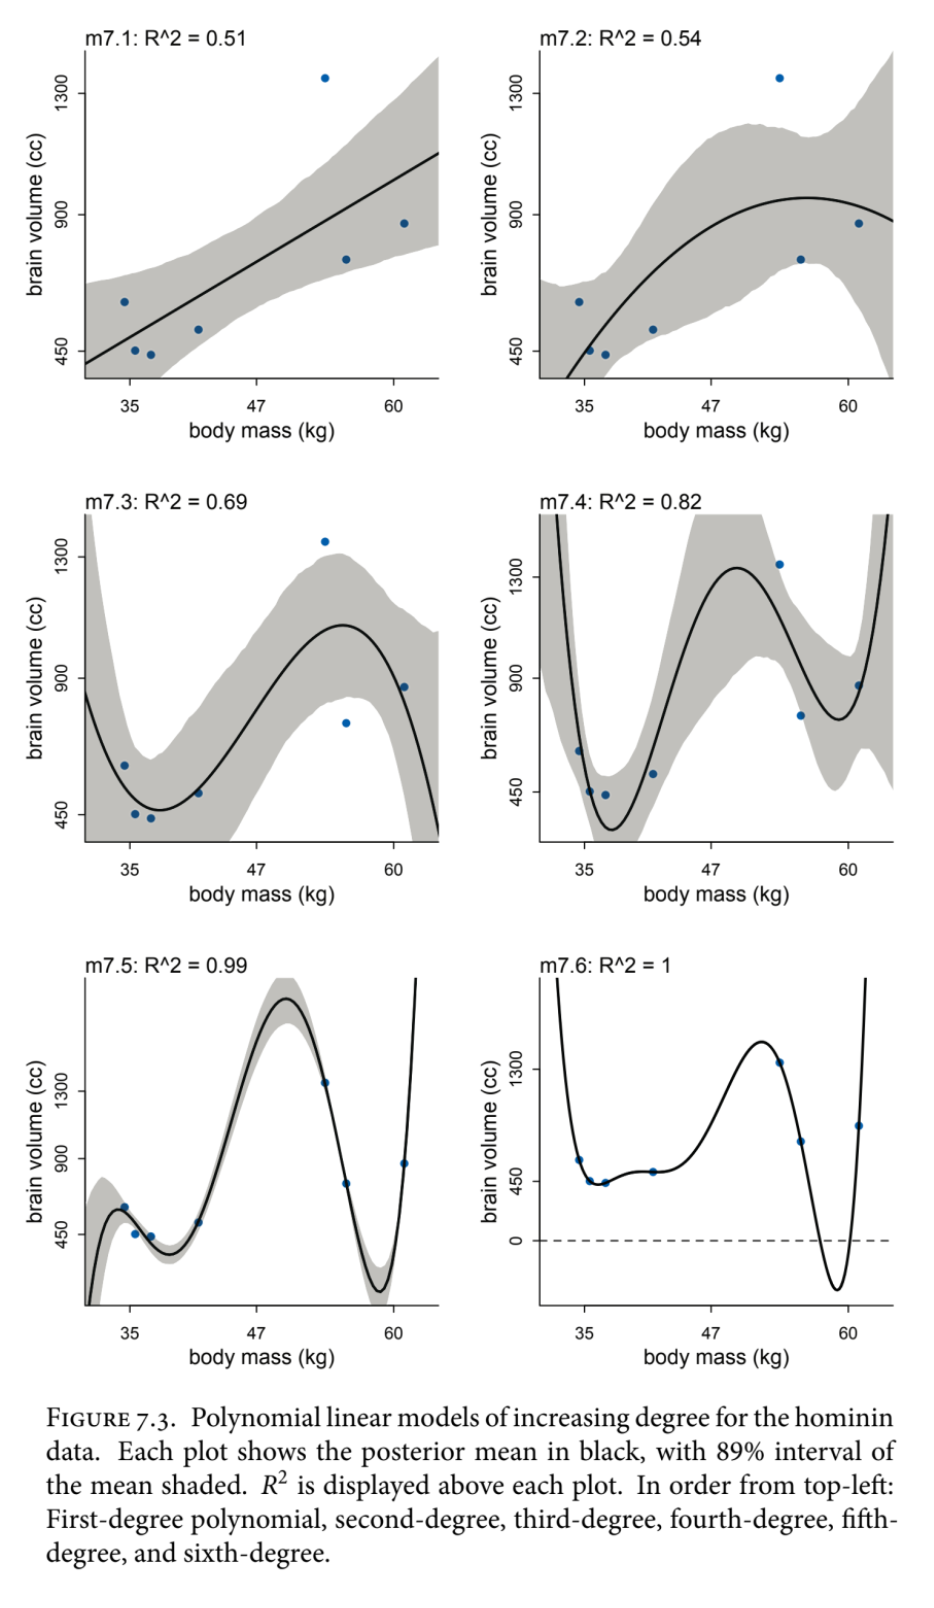

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

Possible regression lines for the 1st degree and 4th degree models.

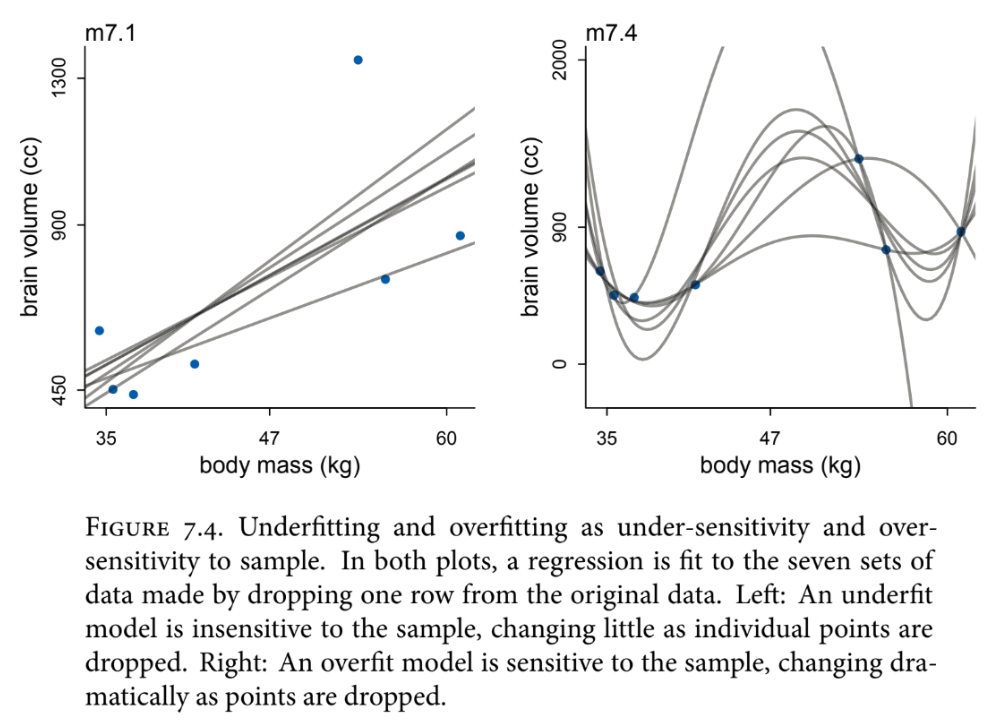

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

First the dataset, body mass vs brain volume for seven hominin species (a biological  taxonomic tribe, including humans).

In [2]:
species = ["afarensis", "africanus", "habilis", "boisei", "rudolfensis", "ergaster", "sapiens"]
brain = np.array([438, 452, 612, 521, 752, 871, 1350])       # brain volume in cc
mass = np.array([37.0, 35.5, 34.5, 41.5, 55.5, 61.0, 53.5])  # body mass in kg

# ddof=1 gives sample-std, which is probably what the book uses
# ddof=0 is the default, the population density
# the function normalizes by the number of sampels minus ddof
mass_std = (mass - mass.mean()) / mass.std(ddof = 1) 
brain_std = brain / brain.max()
# I do not understand why McElreath is unhappy 
# with negative brain volume, but does not mind negative body mass.
# This seems arbitrary.

brains_ds = xr.Dataset({
    "name": ("index", species),
    "brain": ("index", brain),
    "mass": ("index", mass),
    "mass_std": ("index", mass_std),
    "brain_std": ("index", brain_std),
}, coords = {"index": np.arange(len(species))})

brains_ds

<xarray.Dataset> Size: 588B
Dimensions:    (index: 7)
Coordinates:
  * index      (index) int64 56B 0 1 2 3 4 5 6
Data variables:
    name       (index) <U11 308B 'afarensis' 'africanus' ... 'sapiens'
    brain      (index) int64 56B 438 452 612 521 752 871 1350
    mass       (index) float64 56B 37.0 35.5 34.5 41.5 55.5 61.0 53.5
    mass_std   (index) float64 56B -0.7795 -0.917 -1.009 ... 0.917 1.421 0.7336
    brain_std  (index) float64 56B 0.3244 0.3348 0.4533 0.3859 0.557 0.6452 1.0

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

A quick coding of the linear model from the first linear under-fitting example used in the plots above.
Unlike [the PyMC guys](https://github.com/pymc-devs/pymc-resources/blob/main/Rethinking_2/Chp_07.ipynb) we base this on a Bayesian model, not on the single point estimate from the first edition (but see below, if you want the single point version.

In [3]:
mass_1 = brains_ds.mass_std.values
N7 = 6000

# The list for all models, the zeroth position is unused
idata_7 = [None, None, None, None, None, None, None, None]

with pm.Model() as m_7_1: # R_code 7.3 p. 196
    α = pm.Normal('α', mu = 0.5, sigma = 1)
    β = pm.Normal('β', mu = 0,   sigma = 10, shape = 1)
    log_σ = pm.Normal('log_σ', mu = 0, sigma = 1) # could be done with LogNormal instead
    μ = α + β[0] * mass_1                         # Beta is a vector to support higher degree models later
    brain_std = pm.Normal('brain_std', mu = μ, sigma = np.exp(log_σ), observed = brains_ds.brain_std.values)
    idata_7[1] = pm.sample(N7, random_seed = rng)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β, log_σ]


Output()

Sampling 4 chains for 1_000 tune and 6_000 draw iterations (4_000 + 24_000 draws total) took 5 seconds.


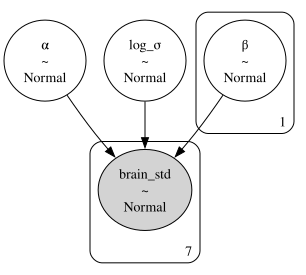

In [4]:
m_7_1.to_graphviz()

In [5]:
az.summary(idata_7[1], kind = 'stats')

,mean,sd,hdi_3%,hdi_97%
α,0.527,0.110,0.323,0.736
β[0],0.167,0.120,-0.051,0.395
log_σ,-1.395,0.377,-2.079,-0.687


Let recreate the posterior plot, just for the first model (for reference purposes, we do not need to discuss this in class).

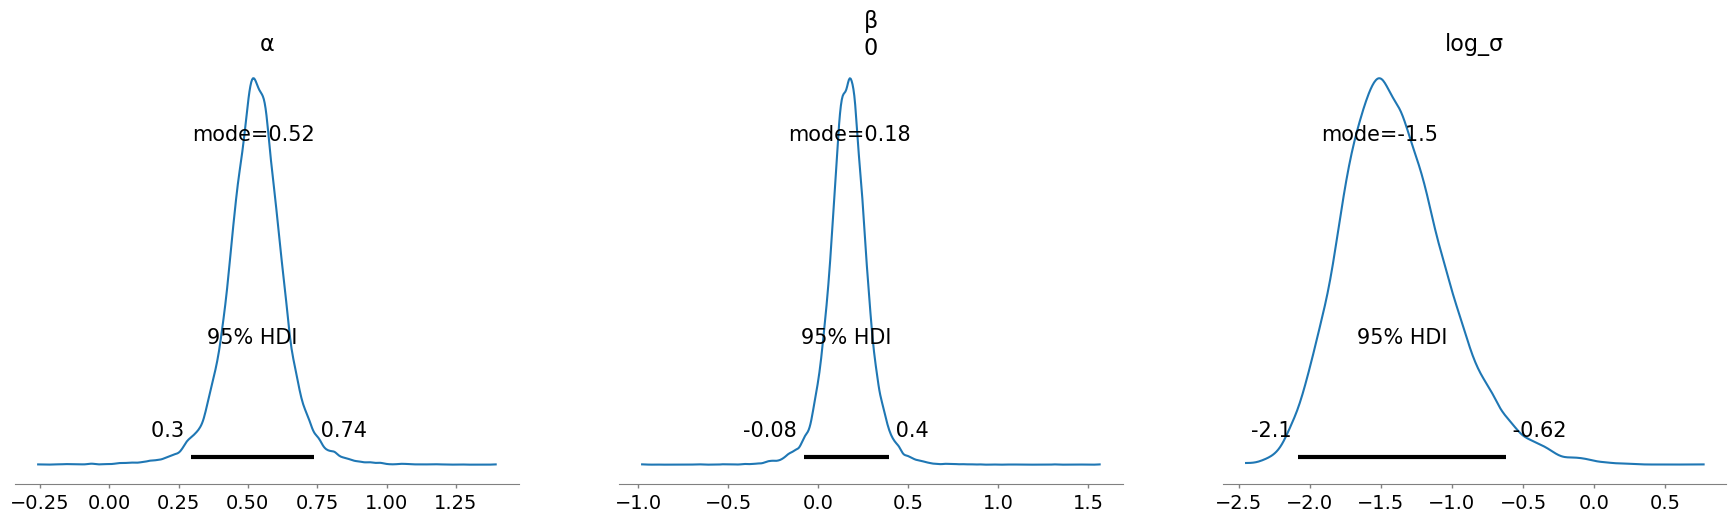

In [6]:
az.plot_posterior(idata_7[1].posterior, 
                      point_estimate='mode', 
                      hdi_prob=0.95,
                      kind="kde");

Sampling: [brain_std]


Output()

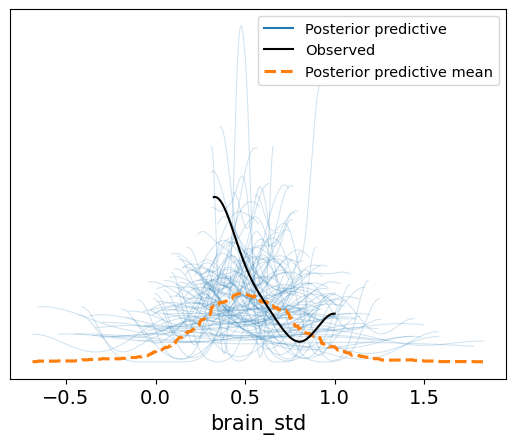

In [7]:
pm.sample_posterior_predictive(idata_7[1], extend_inferencedata = True, model=m_7_1)
az.plot_ppc(idata_7[1], num_pp_samples = 100);

This plot indicates that things are not working

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

We now reproduce the 6 models above in pymc. The details are not important for the lecture (we can skip to save time).  Perhaps, just understand the two first ones, and the naming conventions.

In [8]:
mass_2 = mass_1 * brains_ds.mass_std.values

with pm.Model() as m_7_2: # R_code 7.7 p. 198
    α = pm.Normal('α', mu = 0.5, sigma = 1)
    β = pm.Normal('β', mu = 0,   sigma = 10, shape = 2)
    log_σ = pm.Normal('log_σ', mu = 0, sigma = 1)
    μ = α + β[0] * mass_1 + β[1] * mass_2
    brain_std = pm.Normal('brain_std', mu = μ, sigma = np.exp(log_σ), observed = brains_ds.brain_std.values)
    idata_7[2] = pm.sample(N7, random_seed = rng, target_accept = 0.9)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β, log_σ]


Output()

Sampling 4 chains for 1_000 tune and 6_000 draw iterations (4_000 + 24_000 draws total) took 9 seconds.


In [9]:
mass_3 = mass_2 * brains_ds.mass_std.values

with pm.Model() as m_7_3: # R_code 7.8 p. 198
    α = pm.Normal('α', mu = 0.5, sigma = 1)
    β = pm.Normal('β', mu = 0,   sigma = 10, shape = 3)
    log_σ = pm.Normal('log_σ', mu = 0, sigma = 1)
    μ = α + β[0] * mass_1 + β[1] * mass_2 + β[2] * mass_3
    brain_std = pm.Normal('brain_std', mu = μ, sigma = np.exp(log_σ), observed = brains_ds.brain_std.values)
    idata_7[3] = pm.sample(N7*2, random_seed = rng, target_accept = 0.97)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β, log_σ]


Output()

Sampling 4 chains for 1_000 tune and 12_000 draw iterations (4_000 + 48_000 draws total) took 40 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.


In [10]:
mass_4 = mass_3 * brains_ds.mass_std.values

with pm.Model() as m_7_4: # R_code 7.8 p. 198
    α = pm.Normal('α', mu = 0.5, sigma = 1)
    β = pm.Normal('β', mu = 0,   sigma = 10, shape = 4)
    log_σ = pm.Normal('log_σ', mu = 0, sigma = 1)
    μ = α + β[0] * mass_1 + β[1] * mass_2 \
          + β[2] * mass_3 + β[3] * mass_4
    brain_std = pm.Normal('brain_std', mu = μ, sigma = np.exp(log_σ), observed = brains_ds.brain_std.values)
    idata_7[4] = pm.sample(N7*3, random_seed = rng, target_accept = 0.99)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β, log_σ]


Output()

Sampling 4 chains for 1_000 tune and 18_000 draw iterations (4_000 + 72_000 draws total) took 224 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


In [11]:
mass_5 = mass_4 * brains_ds.mass_std.values

with pm.Model() as m_7_5: # R_code 7.8 p. 198
    α = pm.Normal('α', mu = 0.5, sigma = 1)
    β = pm.Normal('β', mu = 0.0, sigma = 10, shape = 5)
    log_σ = pm.Normal('log_σ', mu = 0, sigma = 1)
    μ = α + β[0] * mass_1 + β[1] * mass_2 + β[2] * mass_3 \
          + β[3] * mass_4 + β[4] * mass_5
    brain_std = pm.Normal('brain_std', mu = μ, sigma = np.exp(log_σ), observed = brains_ds.brain_std.values)
    idata_7[5] = pm.sample(N7*4, random_seed = rng, target_accept = 0.997)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β, log_σ]


Output()

Sampling 4 chains for 1_000 tune and 24_000 draw iterations (4_000 + 96_000 draws total) took 1272 seconds.
There were 96 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


In [12]:
# R_code 7.9 p. 199
mass_6 = mass_5 * brains_ds.mass_std.values
with pm.Model() as m_7_6: 
    α = pm.Normal('α', mu = 0.5, sigma = 1)
    β = pm.Normal('β', mu = 0.0, sigma = 10, shape = 6)
    μ = α + β[0] * mass_1 + β[1] * mass_2 \
          + β[2] * mass_3 + β[3] * mass_4 \
          + β[4] * mass_5 + β[5] * mass_6
    brain_std = pm.Normal('brain_std', mu = μ, sigma = 0.001, observed = brains_ds.brain_std.values)
    idata_7[6] = pm.sample(N7*4, random_seed = rng, target_accept = 0.998)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β]


Output()

Sampling 4 chains for 1_000 tune and 24_000 draw iterations (4_000 + 96_000 draws total) took 2157 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [13]:
mass_seq = np.linspace(30, 65, 400)
mass_seq_std = xr.DataArray((mass_seq - mass.mean()) / mass.std(ddof = 1))

In [14]:
def ch7_plot_posterior(name, idata, ax):
    a_ = idata.posterior.α.sel(chain=0).drop('chain')
    b_ = idata.posterior.β.sel(chain=0).drop('chain')

    # apparently we need to explicitly add a singleton second dimension to be able to execute this sum
    # (and in very similar contexts this works out of the box - Python is just so messy)
    μ_pred_std = np.tile(a_.values.reshape(-1,1), (1,len(mass_seq)))

    # a_.values.reshape(-1, 1) + np.zeros((10000, 30))
    
    # b_.shape[1] gives as the number of betas and [:,i] selects the trace of ith beta 
    for i in range(b_.shape[1]):
        μ_pred_std += b_[:,i] * (mass_seq_std ** (i+1))
        
    μ_pred = μ_pred_std * brain.max()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", FutureWarning)
        # Smoothing (on-by default, introduces some noise here, that makes the HDI not to contain the mean in the last plot)
        az.plot_hdi(mass_seq, y = μ_pred.values, fill_kwargs = hdi_fill_args, smooth = False, hdi_prob = 0.89, ax = ax)
        
    ax.plot(mass_seq, μ_pred.mean(axis = 0), color = 'black', linestyle='-', linewidth = .8)
    brains_ds.plot.scatter(x = 'mass', y = 'brain', color = "black", s = 15, alpha = 0.23, ax = ax)

    ax.set_xlabel("body mass (kg)", fontsize = 'medium')
    ax.set_ylabel("brain volume (cc)", fontsize = 'medium')
    ax.set_ylim(280, 1630)
    ax.set_xlim(30, 64)
    ax.set_title(f'89% HDI for mean predictions from {name}', fontsize = 'medium')
    return ax

/tmp/ipykernel_194153/1074326073.py:2: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  a_ = idata.posterior.α.sel(chain=0).drop('chain')
/tmp/ipykernel_194153/1074326073.py:3: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  b_ = idata.posterior.β.sel(chain=0).drop('chain')
/tmp/ipykernel_194153/1074326073.py:2: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  a_ = idata.posterior.α.sel(chain=0).drop('chain')
/tmp/ipykernel_194153/1074326073.py:3: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  b_ = idata.posterior.β.sel(chain=0).drop('chain')
/tmp/ipykernel_194153/1074326073.py:2: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  a_ = idata.posterior.α.sel(chain=0).drop('chain')
/tmp/ipykernel_194153/1074326073.py:3: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  b_ = idata.p

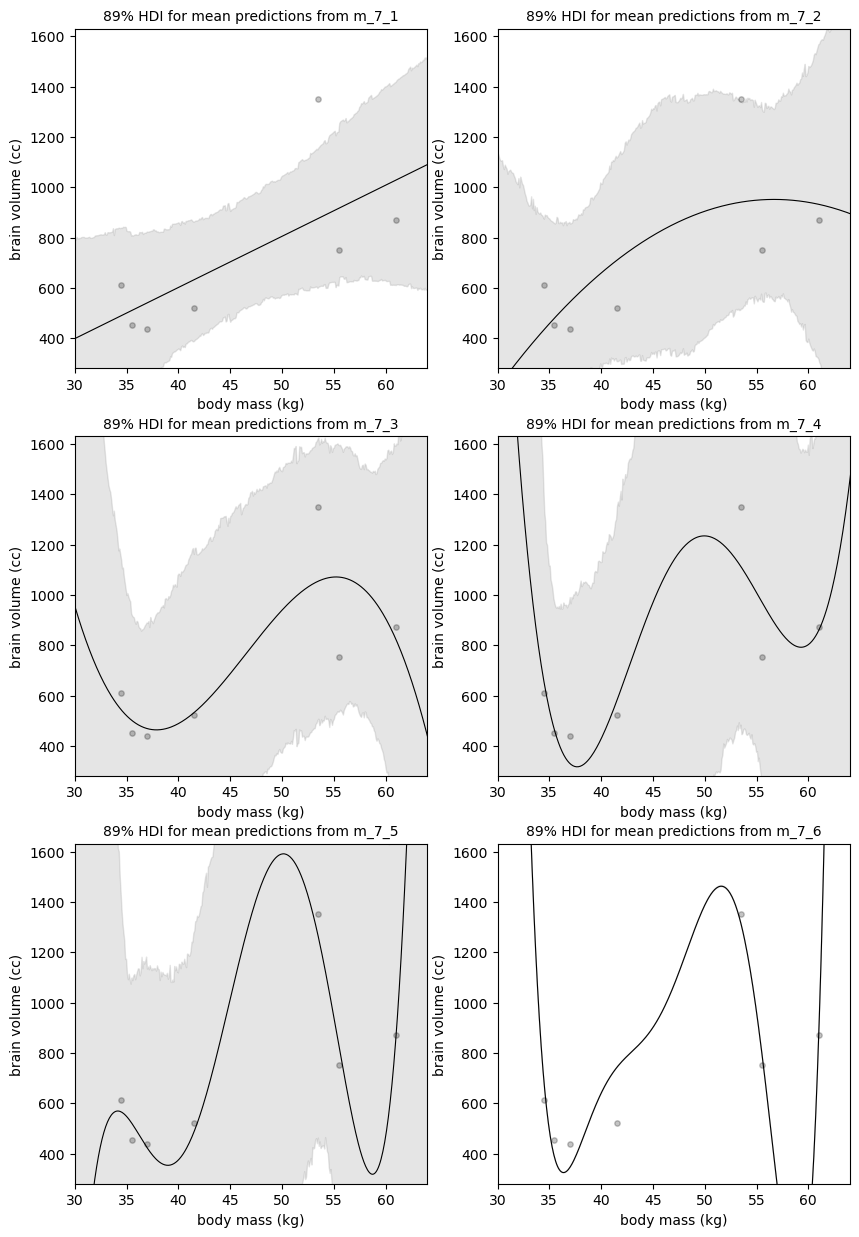

In [15]:
fig, ax = plt.subplots(3,2, figsize = (10, 15))

for i in range(6):
    ch7_plot_posterior(f"m_7_{i+1}", idata_7[i+1], ax[i // 2, i % 2])
plt.show()

The above plot is meant to mimic Fig. 7.3 in the book, but note
* They use quap, not mcmc, so end up with a slightly different approximation.
* The models we created in this chapter are hard to handle for the NUTS sampler (narrow and complex spaces, as all parameters are very dependent)
* The means are approximated very well, essentially the same lines as in the book (or as with the single point estimate code below)
* The endpoints of HDIs are badly estimated
* This is also a problem for quap that assumes the posterior is normal around mean (which means the mean is fine, but the HDI endpoints will be off)
* If you switch off smoothing, the weird separation of HDI and mean disappear. The smoothing algorithm is putting the mean outside the HDI for the last plot.
* Ignore the target_accept argument (two weeks longer). It is there to improve the quality of sampling as these models are quirky (bad by design, and difficult to handle for mcmc).

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

#  Measuring Over/Under Fitting using Information Theory (Section 7.2)

* __Which of the above models is best?__
* Ideally: not the one closest to the sample but the one closest to the (unknown) distribution from which the sample is drawn
* Need: some notion of closeness (distance) of distributions
* Answer: use information theory

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Entropy 

* We begin with defining uncertainty of distributions
* Requirements for measure of uncertainty:

    1. __Continuous:__ a small change of probability values should lead to small changes of uncertainty/information
    2. __Increasing in the number of possible events:__
       more uncertainty about the outcome of a 6-sided die than of a 2-sided coin
    3. __Additive:__ uncertainty of tossing both a coin and a die should be the sum of uncertainties of tossing a die and a coin separately

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

* It turns out that there is exactly one function that satisfies these desiderata, known as __Information Entropy__ (Shannon Entropy, or just entropy):

$$H(p) = - \mathbb{E} \log (p_i) = - \sum_{i=1}^n p_i \log (p_i) $$


* In English: The uncertainty contained in a probability distribution is the expected log-probability over all outcomes.
* **Intuition**: Why log? Measures the number of Y/N questions that need to be asked to resolve the uncertainty.
* How many questions we need to ask to discover what is the outcome of a coin toss?
* Of a 6-sided die toss?
* And then the intuition ends, because outside CS, so in stats/ML, we typically use a natural logarithm, which is not measuring the number of binary questions.
* Fortunately, a base-2 logarithm only differs from a natural one by a constant factor, so this does not matter.

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Example
* Probability of 
    - **p**: rain 0.3 vs sunshine 0.7 is less uncertain than 
    - **q**: rain 0.5 vs sunshine 0.5

In [16]:
p = np.array([0.3, 0.7])
q = np.array([0.5, 0.5])
print(f'The entropy of {p} is {-np.sum(p * np.log2(p))}')
print(f'The entropy of {q} is {-np.sum(q * np.log2(q))}')

The entropy of [0.3 0.7] is 0.8812908992306927
The entropy of [0.5 0.5] is 1.0


**Question:** Why is the uncertainty of p lower than that of q?

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

# KL-Divergence

* Entropy / uncertainty tells us **how hard a distribution is to predict**

* We need a measure of under/over-fitting, so **how far a distribution is from another distribution**.

* * __Divergence__: The additional uncertainty induced by using probabilities from one distribution to describe another distribution. 
    - AKA: **Kullback-Leibler divergence** or **KL-divergence** or **relative entropy**

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

**Def. [KL-divergence]**  
Assume a distribution $p$ which is true (unknown), and distribution $q$ that we use as an approximation (a model posterior), then

$$D_\mathrm{KL}(p,q) = \sum_i p_i\left(\log(p_i) - \log(q_i)\right) = \sum_i p_i \log \left({p_i\over q_i}\right)$$

* KL-divergence measures the uncertainty introduced by using $q$ instead of $p$
* KL-divergence is zero if $p = q$
* KL-divergence grows, when $q$ get's further from $p$

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

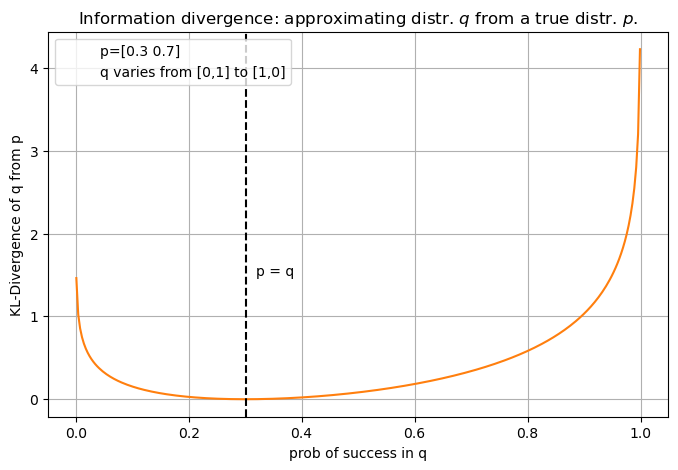

In [17]:
p = np.array([0.3, 0.7])

# D_kl for a simple pair of Bernouli distributions
def dkl(p, q):
    return p[0] * (np.log(p[0]) - np.log(q[0])) + \
           p[1] * (np.log(p[1]) - np.log(q[1]))

qs = np.linspace(0.001, 0.999, 300)
q_ = [[q, 1-q] for q in qs]
dkl_values = [dkl(p, q) for q in q_]

plt.figure(figsize=(8, 5))
plt.plot(qs, dkl_values, '-', color = "C1") 

plt.axvline(x = qs[np.argmin(dkl_values)], linestyle = '--', color = 'black')
plt.text(0.32, 1.5, "p = q")
plt.plot([], [], ' ', label=f'p={p}')
plt.plot([], [], ' ', label=f'q varies from [0,1] to [1,0]')


plt.xlabel("prob of success in q")  # Horizontal axis label
plt.ylabel('KL-Divergence of q from p')  # Vertical axis label
plt.title('Information divergence: approximating distr. $q$ from a true distr. $p$.')  # Plot title
plt.legend()  # Show legend

# Show the plot
plt.grid(True)  # Optional: Add grid lines for better readability
plt.show()


* Divergence can only equal zero when $q = p$ (dashed line)
* Otherwise it is positive
* Grows as $q$ becomes more dissimilar from $p$
* If you have several model distributions approximating $p$, it would be nice to pick the one with lowest divergence from the target

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Log-Pointwise-Predictive-Density (LPPD)

* __Problem__: when we want to estimate overfitting/underfitting, we would like to see how far we are from the target distribution, but __the target distribution $p$ is unknown!__

* __Solution__: instead of measuring how far a model is from the target distribution, we can __compare them__.
* Check which one of $q$, $r$ is closer to the unknown target distribution $p$: 

$$
\begin{align}
D_\mathrm{KL}(p,q) - D_\mathrm{KL}(p,r) & = \mathbb{E}_p (\log p - \log q) - \mathbb{E}_p (\log p - \log r) \phantom{\sum_i} \\
& = \sum_i p_i (\log p_i - \log q_i) - \sum_i p_i (\log p_i - \log r_i) \\
& = \sum_i p_i (\log p_i - \log q_i - \log p_i + \log r_i) \\
& = \sum_i p_i (\log r_i - \log q _i) \\
& = \mathbb{E}_p \log r_i - \mathbb{E}_p \log q_i \tag{$\ast$}\\
\end{align}
$$

* It turns out we can estimate $\mathbb{E}_p\log r_i$ with $S(r) = \sum_i \log (r_i)$ without knowing $p$, just using values (the $i$ index) sampled from the unknown distribution $p$ - the observed data. We will call this estimation LPPD.

* In Bayesian setting this can be done by estimating probability for each observed outcome in the posterior ($r$ or $q$). Bayesian means that we have to do it for the entire distribution of parameter values in the posterior.


<br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Estimating LPPD with a Bayesian Posterior
LPPD below approximates just one of the terms in (*) above, so $p$ below stands for $r$ or for $q$ in (\*). And when we compare models we need to calculate lppd for each of them.

$$\textrm{lppd}(y, \Theta)  = \sum_i \log {1\over S} \sum_s p(y_i\mid \Theta_s)$$

where
  - $p$ is the model (the posterior density)
  - $S$ is the number of samples from posterior
  - $\Theta_s$  is the $s$-th set of sampled parameter values.
  - $i$ ranges over the ground truth data points (observed data)
  - We basically average the terms from the above over the posterior.
  - Higher the lppd is better, better match of the posterior with the data

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

# An Implementation of LPPD (example)

In Python. 

We write our own lppd function like in R code 7.14 on p. 211  

Unfortunately, this seems a bit cumbersome with PyMC model.  
I do not see how it is possible to ask PyMC for a probability of  
an observed data point given a model and parameters.

Instead I provide to lppd a posterior sample and a function `log_prob`  
that given a vector of model parameters computes the probability like  
in the model. This function is redundant, as it carries the same  
information already present in the model. But for now I cannot see how  
to eliminate this redundancy.

In [40]:
def lppd(idata: az.InferenceData, 
         log_prob: Callable[[NDArray[np.float64], NDArray[np.float64]], np.float64], 
         observations: NDArray[np.float64]) -> np.float64:
    '''
    observation  A (k,l) shaped for k - number the observations, l - dimensions of each observations
    idata        An inference data object with a posterior group
    log_prob     Expects an (l,) vector of observations (an l-dimensional point) and a slice of idata 
                 posterior for 1 draw (a DataArray) 
    '''
    N_samples = idata.posterior.sizes['draw']

    # a row per parameter, a column per sample (so N_samples columns)
    params = idata.posterior.sel(chain=0).drop_vars('chain')

    # a row per observation (so N_obs rows), a column per sample (N_samples columns)
    log_probs = np.array([np.array([log_prob(obs, params.sel(draw=draw).drop_vars('draw')) 
                                    for draw in range(N_samples)]) 
                          for obs in observations])

    # logsumexp should do the same as first exp, then sum, and then log, but more numerically precisely
    # if our array was 'probs' not 'log_probs' then we would do just sum and log, but this is 
    # numerically less stable
    scores = logsumexp(log_probs, axis = 1) - np.log(N_samples)
    print(f"Individual scores: {scores}")
    return scores.sum()

Bigger values of lppd are better, in the sense that they match the data better.

Let's implement `log_prob` for model `m_7_1` and use it to calculate the model's lppd.

In [41]:
def m_7_1_logprob (obs: NDArray[np.float64], params: xr.Dataset) -> np.float64:
    '''obs    - a numpy array (2,) containing a vector representing a 2-dimensional observation point [mass_std, brain_std]
       params - an xarray Dataset, a slice of inference data posterior group containing one draw from a posterior.
    '''
    μ = params.α.values.item() + params.β.values.item() * obs[0]
    return stats.norm.logpdf(obs[1], loc = μ, scale = np.exp(params.log_σ.values.item()))
    
def m_7_2_logprob (obs: NDArray[np.float64], params: xr.Dataset) -> np.float64:
    μ = params.α.values.item() + params.β.values[0] * obs[0]        + params.β.values[1] * (obs[0] ** 2)
    return stats.norm.logpdf(obs[1], loc = μ, scale = np.exp(params.log_σ.values.item()))
    
def m_7_3_logprob (obs: NDArray[np.float64], params: xr.Dataset) -> np.float64:
    μ = params.α.values.item() + params.β.values[0] * obs[0]        + params.β.values[1] * (obs[0] ** 2) \
                               + params.β.values[2] * (obs[0] ** 3)
    return stats.norm.logpdf(obs[1], loc = μ, scale = np.exp(params.log_σ.values.item()))
    
def m_7_4_logprob (obs: NDArray[np.float64], params: xr.Dataset) -> np.float64:
    μ = params.α.values.item() + params.β.values[0] * obs[0]        + params.β.values[1] * (obs[0] ** 2) \
                               + params.β.values[2] * (obs[0] ** 3) + params.β.values[3] * (obs[0] ** 4)
    return stats.norm.logpdf(obs[1], loc = μ, scale = np.exp(params.log_σ.values.item()))
    
def m_7_5_logprob (obs: NDArray[np.float64], params: xr.Dataset) -> np.float64:
    μ = params.α.values.item() + params.β.values[0] * obs[0]        + params.β.values[1] * (obs[0] ** 2) \
                               + params.β.values[2] * (obs[0] ** 3) + params.β.values[3] * (obs[0] ** 4) \
                               + params.β.values[4] * (obs[0] ** 5)
    return stats.norm.logpdf(obs[1], loc = μ, scale = np.exp(params.log_σ.values.item()))
    
def m_7_6_logprob (obs: NDArray[np.float64], params: xr.Dataset) -> np.float64:
    μ = params.α.values.item() + params.β.values[0] * (obs[0])      + params.β.values[1] * (obs[0] ** 2) \
                               + params.β.values[2] * (obs[0] ** 3) + params.β.values[3] * (obs[0] ** 4) \
                               + params.β.values[4] * (obs[0] ** 5) + params.β.values[5] * (obs[0] ** 6)
    return stats.norm.logpdf(obs[1], loc = μ, scale = 0.001)

In [42]:
observations = brains_ds[['mass_std', 'brain_std']].to_array().values.T

In [43]:
models = [(idata_7[1], m_7_1_logprob), (idata_7[2], m_7_2_logprob), (idata_7[3], m_7_3_logprob), 
          (idata_7[4], m_7_4_logprob), (idata_7[5], m_7_5_logprob), (idata_7[6], m_7_6_logprob)] 
scores = [lppd(idata, logprob, observations) for idata, logprob in models]
print(f"\nScores for models 1-6: {scores}")

Individual scores: [ 0.37875213  0.40374038  0.3274723   0.39604706  0.27306613  0.23221366
 -0.60657878]
Individual scores: [ 0.28325649  0.30062502  0.11624045  0.12668955  0.11274811  0.12558892
 -0.33989854]
Individual scores: [ 0.26247592  0.24289703  0.1475914   0.12015602 -0.19143946  0.04795412
 -0.13888158]
Individual scores: [ 0.06809839  0.22114657  0.06900115  0.05023332 -0.0526403   0.0263844
 -0.05260953]
Individual scores: [0.30380452 0.35843199 0.26208486 0.26672095 0.26339374 0.24633512
 0.26255643]
Individual scores: [-2.12386218e+03 -1.09527185e+03 -1.04520821e+03 -1.30440375e+04
 -6.14283915e+02  3.17118388e+00 -3.01413211e+02]

Scores for models 1-6: [1.4047128836072051, 0.7252500180704828, 0.49075345440364515, 0.3296140030850019, 1.9633276137229085, -18220.905679232754]


* We get a different series of LPPD scores because models 1-5 are really bad, especially the middle ones get very bad.
* The final one has the same as LPDD score in the book, as it is the same one as in the book
* Still we end up with the conclusion that the best score is for the most over-fitting model
* The problem seems to be evaluating on training data

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

The following code (skipped in class)  is the ordinary linear regression 
version of the above (as in the R code 7.4 p 196 but using Python's libraries).  
This single-point estimate version is close to the book, so another explanation of discrepancies of mcmc plots and the book could be not quap, but perhaps the book copied the plots from the 1ed, which did use single-point estimates.

In [22]:
import statsmodels.formula.api as smf
m_7_1_ols = smf.ols("brain_std ~ mass_std", data = brains_ds).fit()
m_7_1_ols.summary()

/home/wasowski/miniconda3/envs/prpro-2025/lib/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              brain_std   R-squared:                       0.490
Model:                            OLS   Adj. R-squared:                  0.388
Method:                 Least Squares   F-statistic:                     4.807
Date:                Tue, 25 Feb 2025   Prob (F-statistic):             0.0798
Time:                        19:47:25   Log-Likelihood:                 2.9925
No. Observations:                   7   AIC:                            -1.985
Df Residuals:                       5   BIC:                            -2.093
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5287      0.071      7.492      0.001       0.347       0.710
mass_std       0.1671      0.076      2.192      0.080      -0.029       0.363
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   1.561
Prob(Omnibus):                    nan   Jarque-Bera (JB):                2.372
Skew:                           1.399   Prob(JB):                        0.305
Kurtosis:                       3.548   Cond. No.                         1.08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [23]:
# An lppd function consistent with the single point estimate variant above
from patsy import dmatrix


def lppd_1(model, n_samples=1e4):
    n_samples = int(n_samples)

    pars = stats.multivariate_normal(model.params, model.cov_params()).rvs(n_samples).T
    dmat = dmatrix(
        model.model.data.design_info, brains_ds, return_type="dataframe"
    ).values  # get model design matrix
    pred = dmat.dot(pars)

    n, ns = pred.shape

    # this approach for calculating lppd isfrom 7.14
    sigmas = (np.sum((pred - brains_ds.brain_std.values.reshape(-1, 1)) ** 2, 0) / 7) ** 0.5
    ll = np.zeros((n, ns))
    for s in range(ns):
        logprob = stats.norm.logpdf(brains_ds.brain_std.values, pred[:, s], sigmas[s])
        ll[:, s] = logprob

    lppd = np.zeros(n)
    for i in range(n):
        lppd[i] = logsumexp(ll[i]) - np.log(ns)

    return lppd

lppd_1(m_7_1_ols).sum()

2.5300981395359727

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Deviance

In [24]:
def deviance(idata: az.InferenceData, 
         log_prob: Callable[[NDArray[np.float64], NDArray[np.float64]], np.float64], 
         observations: NDArray[np.float64]) -> np.float64:
    '''
    observation     A (k,l) shaped for k - number the observations, l - dimensions of each observations
    idata.posterior An inference data object with (m, parameters) and n draws
    log_prob        Expects an (l,) vector of observations (1 point) and (m,) vector of parameters 
                    in the same order as in the inference data.
    '''
    return - 2.0 * lppd(idata, log_prob, observations)

__Deviance__ = -2 * lppd  

* (smaller the better, remember that the actual values mean nothing, but relative differences across models matter)

* Using lppd or deviance on the same set we use for fitting still does not work.
  
* It will always say that better models are those which have more parameters (overfit)

* Instead, we would like to split the observation data we have into a __training sample__ and a __test sample__.
* This way we can estimate how the model behaves on new data.


<br/><br/><br/><br/><br/><br/><br/><br/><br/>

**An Example**

1. Training sample of size $N$
2. Compute the posterior using the training sample, and compute the score of the model for it.
3. Take another sample of size $N$ from the same process, a _test sample_
4. Compute the model score for the test sample, using the same posterior obtained from the training sample.

We get a plot like below for 5 different models, with increasing numbers of parameters (from a bivariate linear model, not shown here). The generative model has three parameters (so we expect that somehow the best fit should be with three).

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

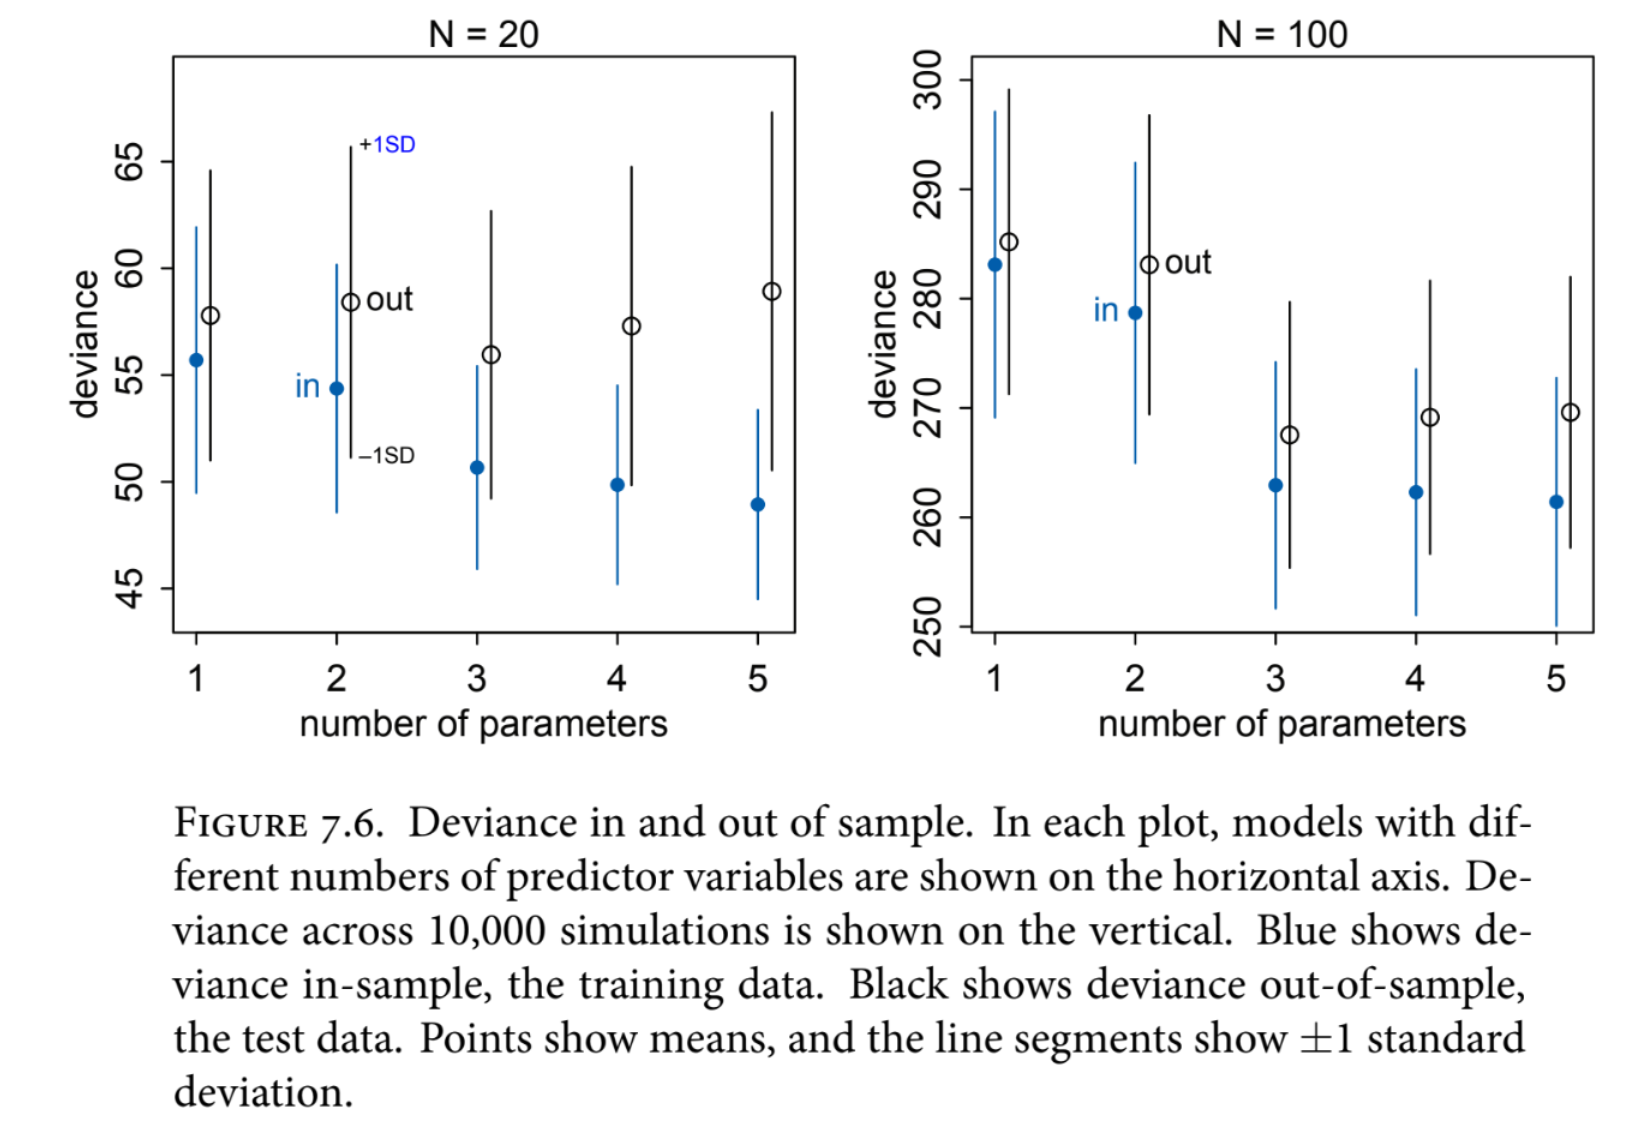

* Note that deviance gets better on the training sample, when the fit is improving (the number of parameters is growing)
* However the deviance on the test samples is growing, from some point so the out-of-sample fit is getting worse
* The figure shows that we can use deviance to see which model fits best (out of the five) but on the __out-of-sample__ score.
* Also note the large standard deviation bars: for each individual pair of samples we can say very little - we need simulate many times to make any useful conclusion using means.

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Regularization (Section 7.3)

* One way to make the model less excited about the sample is to use a skeptical prior
* It will take more samples then, to turn it around, and the posterior will react more "stubbornly" by not creating so irregular overfit shapes.
* A prior $\textrm{Normal}(0, 100)$ is basically flat, so gives the data a lot of influence.
* A prior $\textrm{Normal}(0, 1)$ says that the fitting should be very skeptical about values below -2 and above 2. So it will do some regularization.
* This is a reason not to use too weak priors, but always capture what we know in the priors. **Weak priors encourage overfitting**
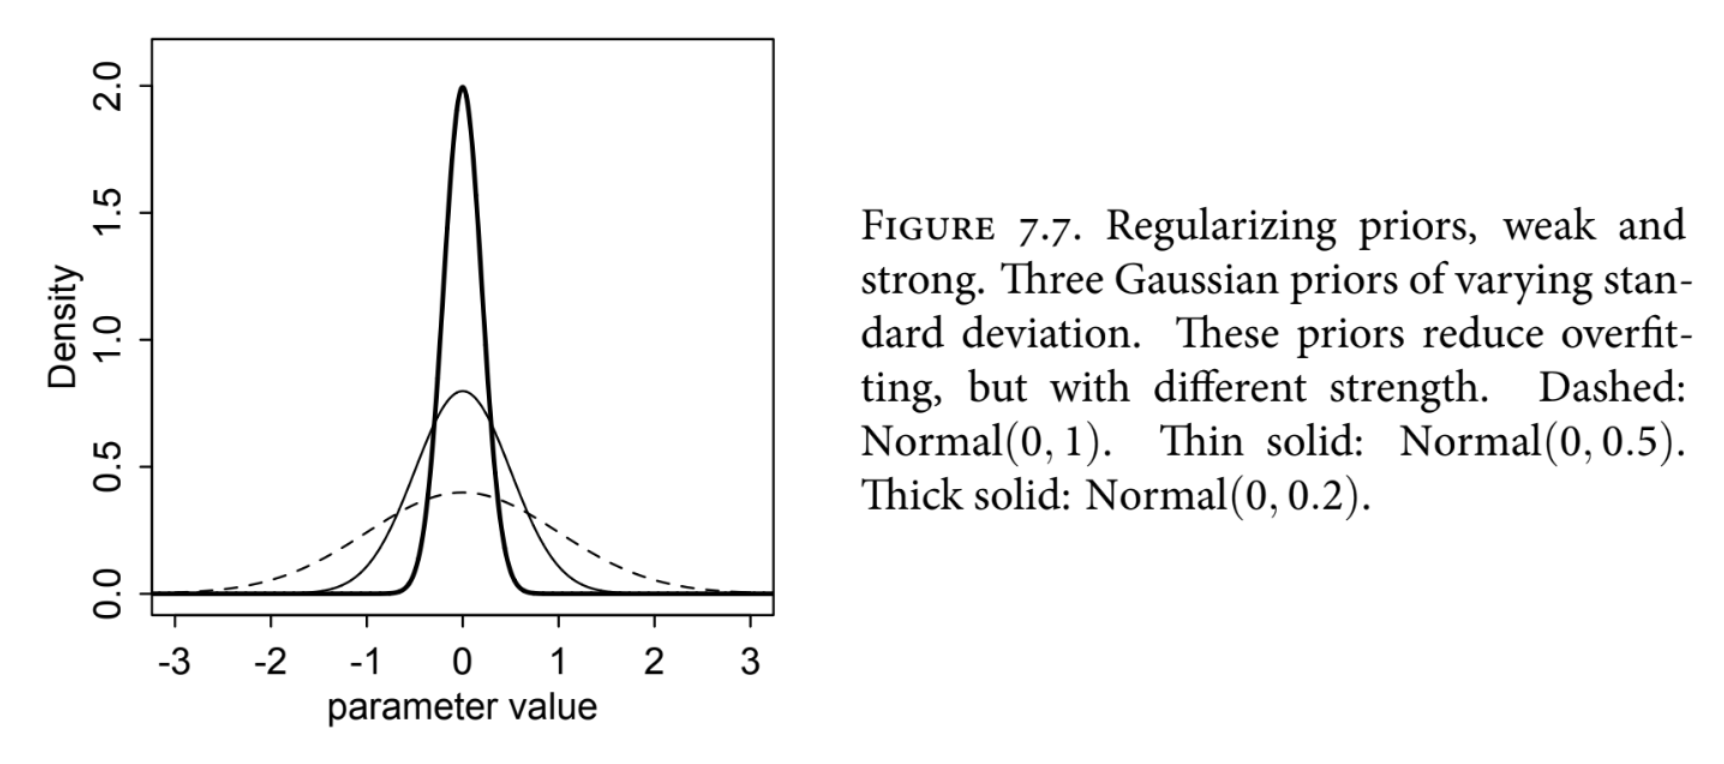

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

* Of course when you reduce overfitting, you increase the risk of underfitting.
* Also you  prior should still only contain prior knowledge, and not be biased in anyway by the data you are seeing.

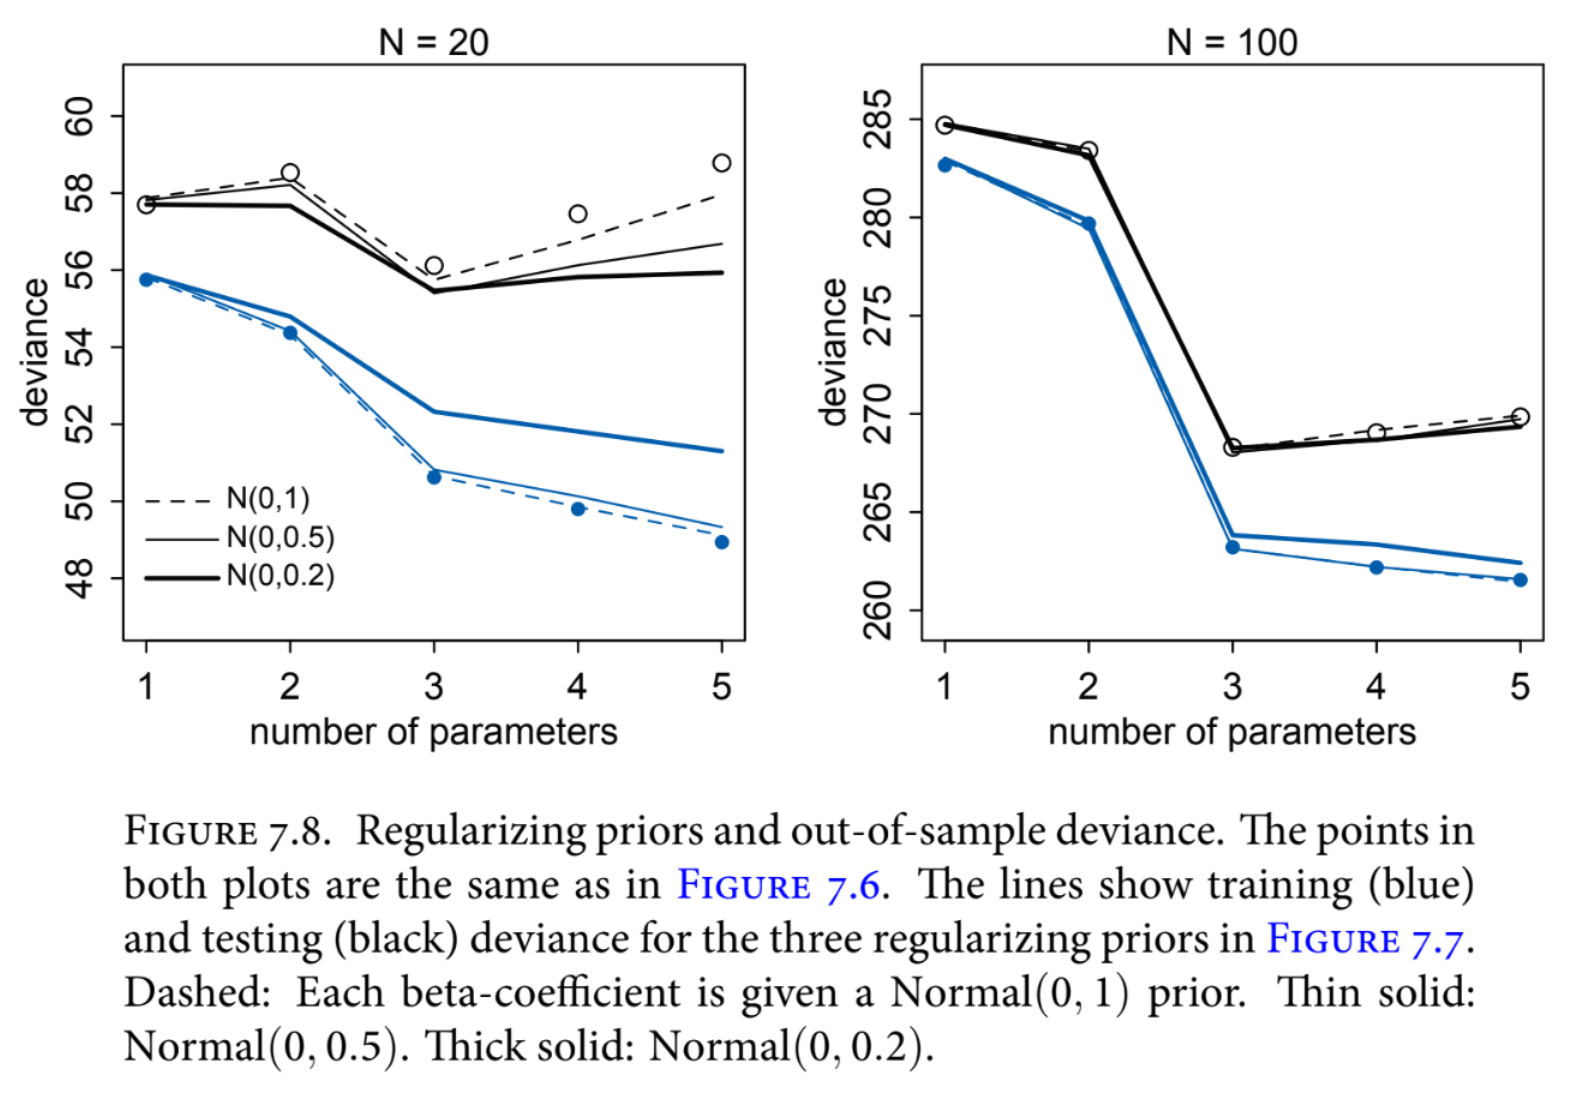

* Note how the stronger priors make deviance worse for in-sample data on more complex models
* Note: the stronger regularizing priors __improve__ the deviance for complex models for out-of-sample data
* Observe: how stronger piors make the complex models look better than weak priors.
* At the same time a larger sample is able to overcome this gain (right)
* (the previous figure, 7.6, was using a very weak prior)

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Cross Validation (Section 7.4.1) 

* We know we can use deviance to predict accuracy, but how do we get out-of-sample data?


* A popular strategy for estimating predictive accuracy is __cross validation__


* The idea: 
    1. split your data set into two parts: training and testing, evaluate the accuracy on testing
    2. Repeat the process for diffent splits
    3. Calculate average out-of-sample accuracy (or other metrics) across different splits
* The sample accuracy metric we can use is deviance of the posterior predictive distribution

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

* How many different splits should we use?
* In (my area of) computer science, splitting into 10 parts, training on 9, testing on 1 is very common
* __Leave-One-Out Cross-Validation__ (LOO CV): 
  - an extreme split, we train on all but one observation, use the last one for testing/scoring. 
  - we repeat this for all observations: using each observation for testing once
  - then we average the score over all these attempts


* The textbook shows a trick how this can be done without refitting the posterior for each observation (which could be very many) using __Pareto-Smoothed Importance Sampling__ (PSIS) cross validation.
  - the simple intuition is that one can fit the posterior once, and adjust it for removing one observation from the set, so this becomes computationaly feasible
  - PSIS is an estimator of CV (which is already an estimator ...)
 
* LOO and PSIS are implemented in arviz (https://www.pymc.io/projects/docs/en/stable/learn/core_notebooks/model_comparison.html)

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Widely Applicable Information Criterion (WAIC, p. 220)

* Information criteria attempt to use information theory to understand the accuracy (the expected score out-of-sample)
* They are basically magic :) 
* Intuition: if the posterior is very tight then it has low entropy, so information theory can help to understand how tightly it fits the data (like with lppd)

* This is __WAIC__:

$$\textrm{WAIC}(y, \Theta) = -2 \left(\textrm{lppd} - \sum_i\textrm{var}_{\Theta} \log p(y_i \mid \Theta)\right)$$

* where 
    - $y$ is the observations and $\Theta$ is the posterior distribution (recall that it talks about the unknown parameter values).
    - lppd is taken over posterior predictive density

* This is magic, because we can get an estimation of out-of-sample deviance without any test set.

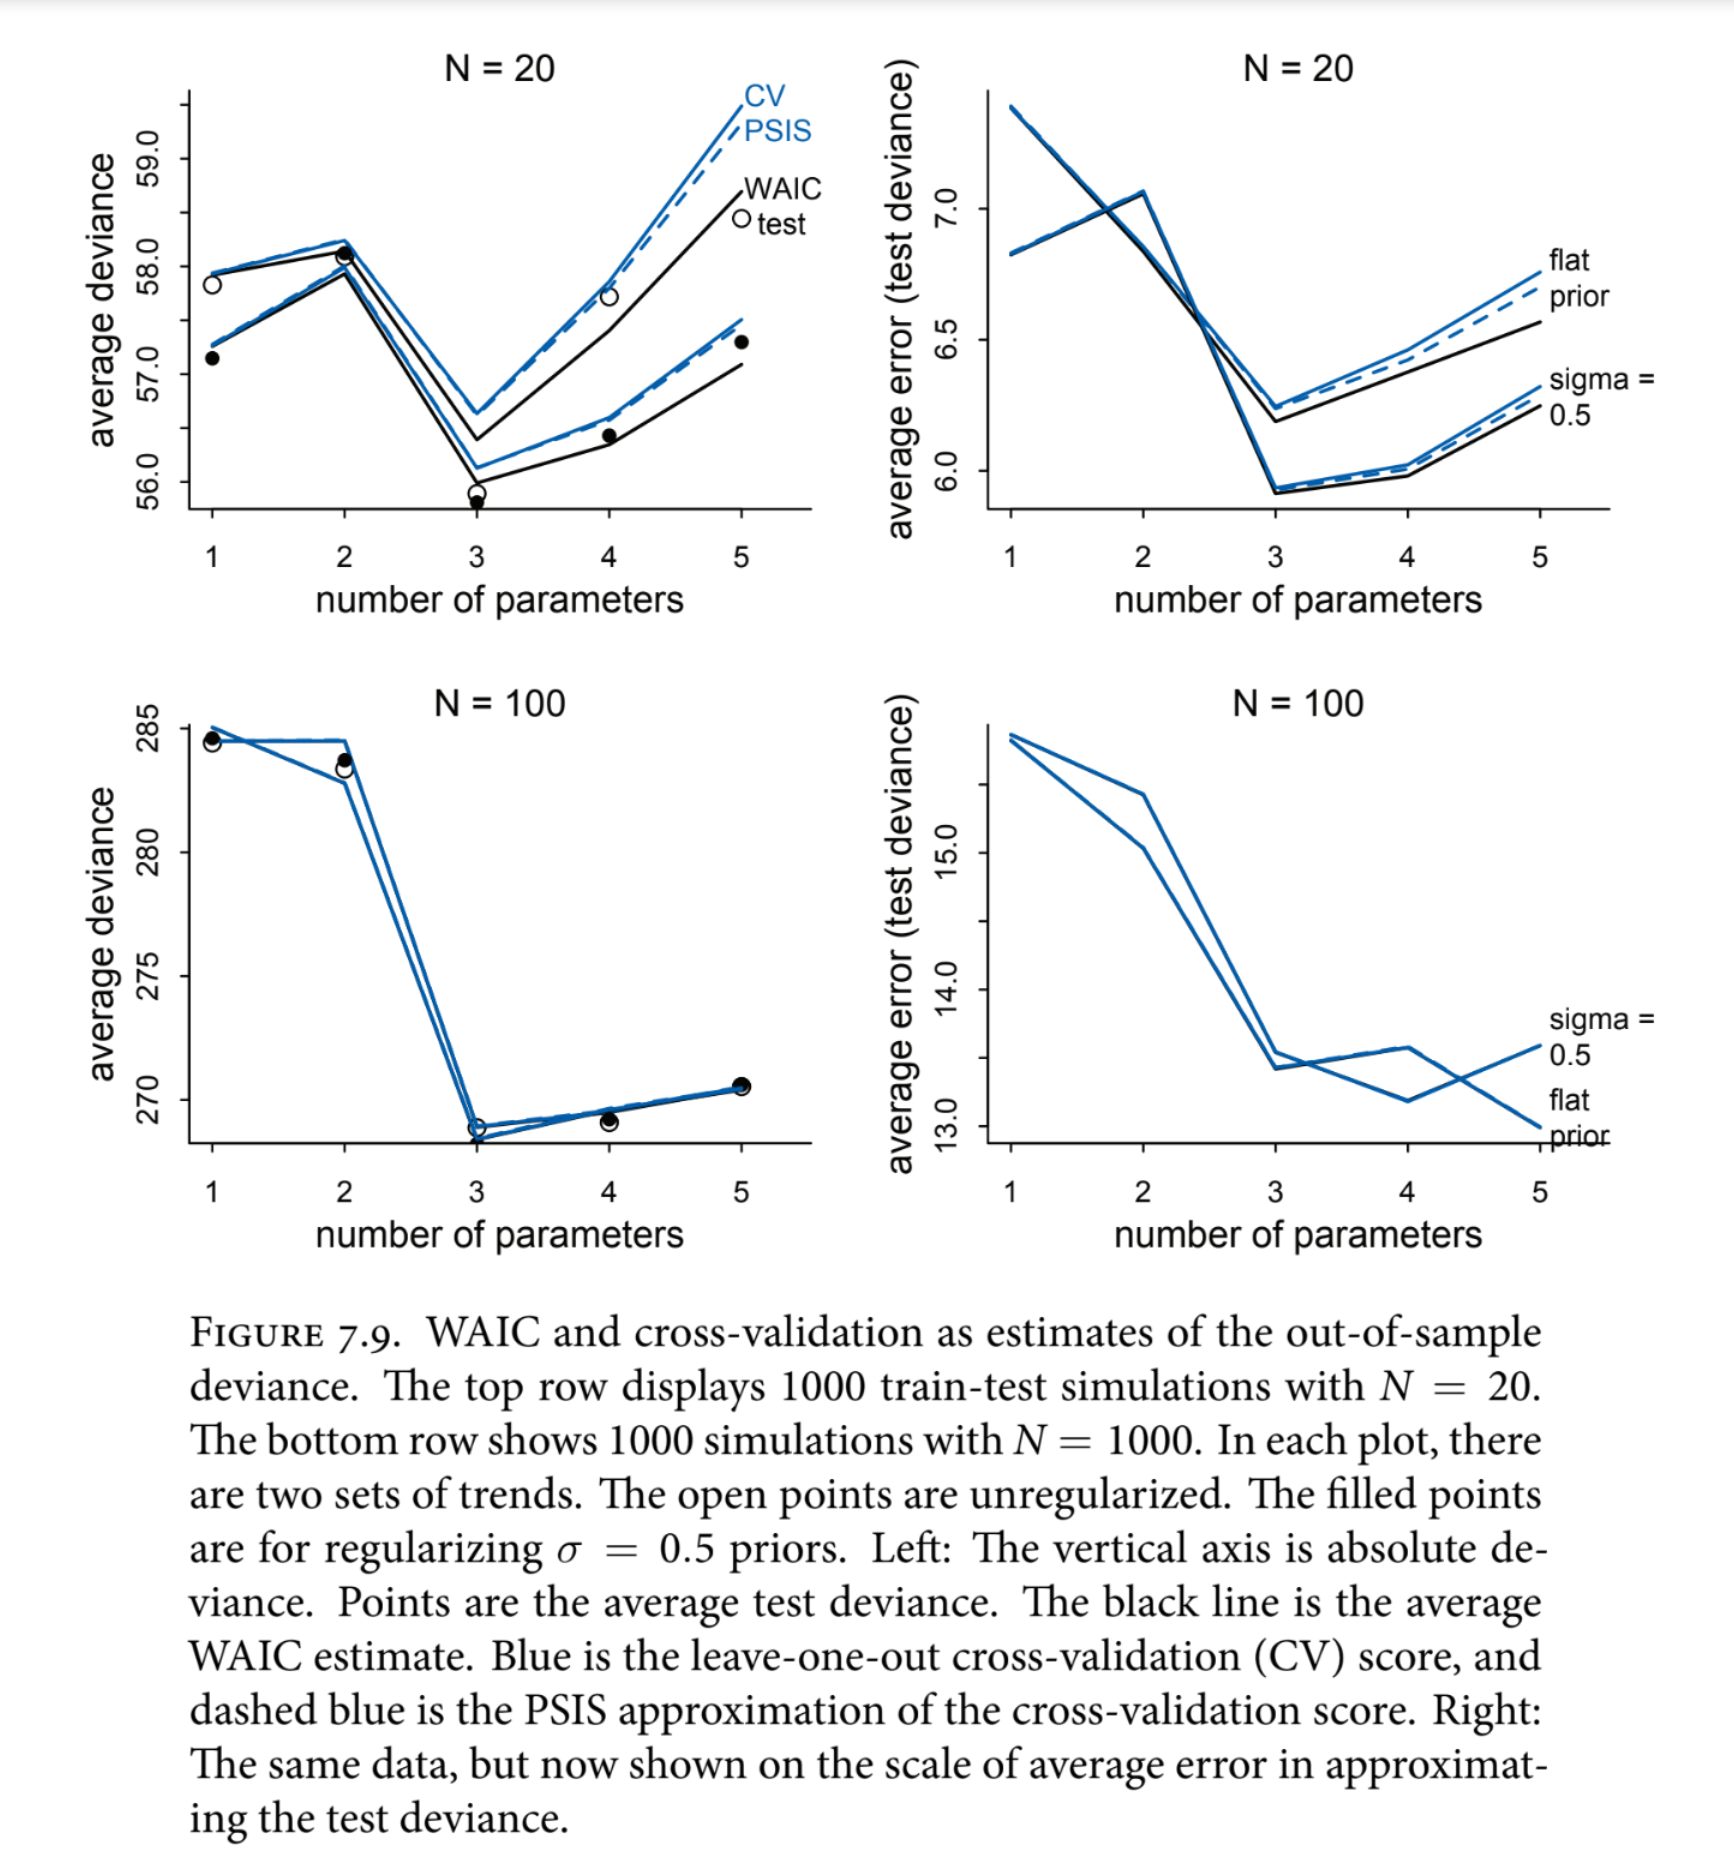

* All points are out-of-sample deviance (not like in previous graphs)
* The regularizing priors overfit less (filled regularized, open not regularized)
* All three methods do pretty well (left plots)
* For large sample they pretty much converge
* WAIC is a bit better if you look at the error plots
* Arviz has an implementation of WAIC (https://www.pymc.io/projects/docs/en/stable/learn/core_notebooks/model_comparison.html)

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Correlation is not Causation (Revisitted, Section 7.5)

* The best generalizing (best predicting) models can be confounded
* For instance for our fungi-treatment example the best predicting model conditions on the post-treatment effect
* Prediction and Causation are two very different things
* The backdoor paths do carry valid information for prediction, while obscuring causation.
* So you need to understand what kind of model you are building
* The book shows that for the fungi example the confounded model has best prediction metrics.

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Robust Regression (p. 233-234)

* Outliers also destroy the predictive power of models
* They tend to adversely influence the inference with Normal priors 
* A normal distribution has relatively slim tails
* If an observation appears far out of the mean, it may shift the mean, or weaken the standard deviation
* If you have outliers, the right thing to do, is not to remove them (as often done in frequentist statistics), but to use a prior that allows outliers (Gaussian does not really).
* A standard distribution that admits **fat tails** is the **Student-T distribution**
* A Student-T distribution has the same parameters as Gaussian (mean and variance) plus a new shape parameter $\nu$ ranging over non-negative reals that controls the thickness of tails. 
* For large $\nu$ we get a Gaussian (perfect for $\nu=\infty$). For low $\nu$ we get very thick tails:


<br/><br/><br/><br/><br/><br/><br/><br/><br/>

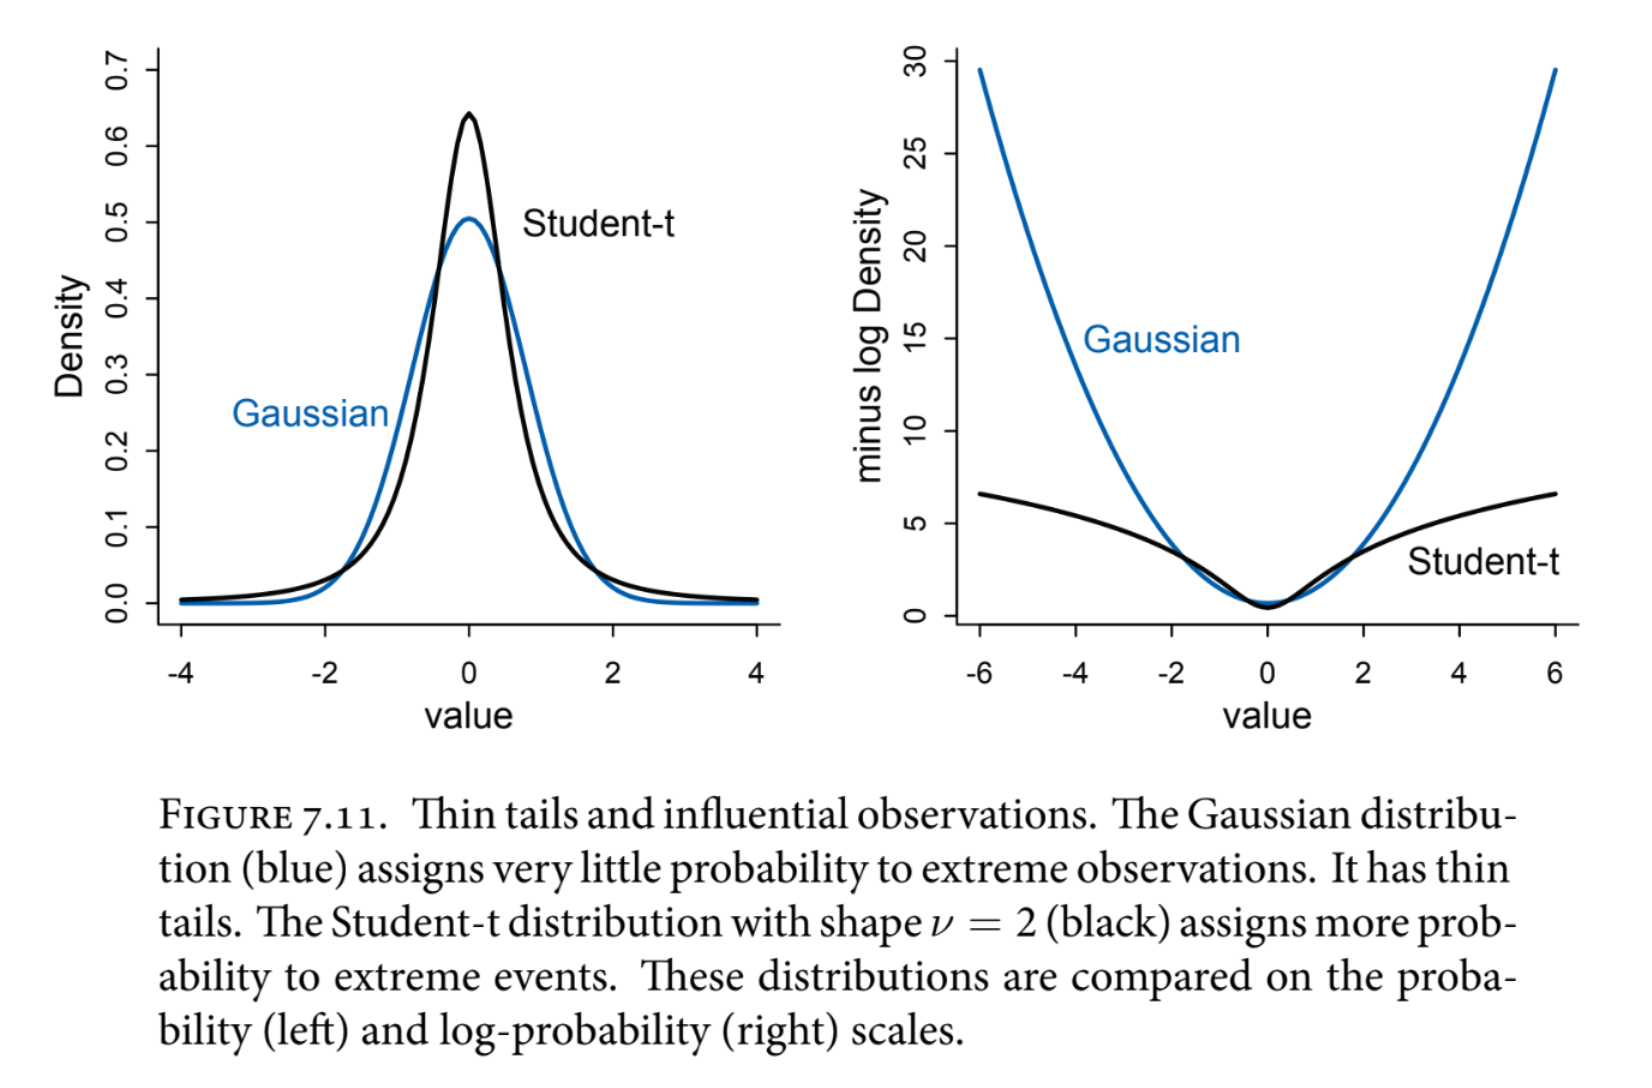

The figure is a bit unclear because we do not know the parameters for the Gaussian and Student-T.  
Let's plot it ourselves below.

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

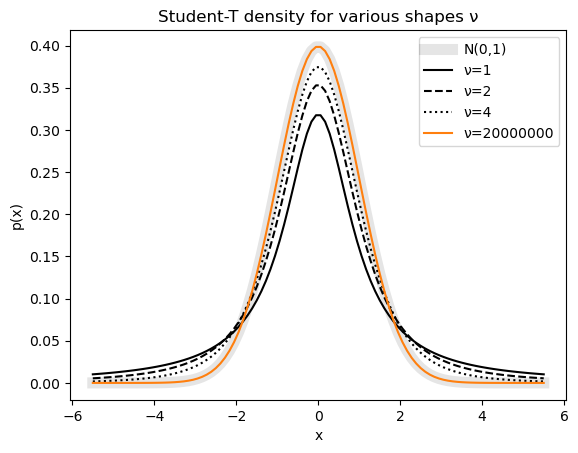

In [25]:
x = np.linspace(-5.5,5.5,100)

colors = ['black', 'black', 'black', 'C1']
linestyle = [ '-', '--', ':', '-']
ν = [1,2,4,20000000]

plt.plot(x, stats.norm.pdf(x, loc = 0, scale = 1), label = 'N(0,1)', 
             linestyle = '-', color = "black", lw=8, alpha = 0.1)

for i in range(len(colors)):
    plt.plot(x, stats.t.pdf(x, df = ν[i], loc = 0, scale = 1), label = f'ν={ν[i]}', 
             linestyle = linestyle[i], color = colors[i])


plt.xlabel('x')
plt.ylabel('p(x)')
plt.title('Student-T density for various shapes ν')
plt.legend()
plt.show()

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

For completeness, the PDF of the Student-t distribution:
$$
p(x \mid \mu, \sigma, \nu) = {\Gamma ({\nu + 1 \over 2}) \over \sqrt {\pi\nu} \, \Gamma({\nu \over 2})} \left( 1 + {x^2 \over \nu} \right)^{-(\nu+1)/2}
$$

where

$$
\Gamma(z) = \int_0^\infty t^{z-1}e^{-t} \mathrm{d}t
$$

but we won't be using the analytical formulation further on in this course.

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Example on better fitting data with the $t$ distribution

* Below we show the _maximal likelihood estimates_ for 5 "toy" data
  points, _i.e._, the values for normal and $t$ distributions that
  better fit the data.
  * Formally speaking, given the dataset $D$, parameters were found
    that maximize likelihood functions $p(D\mid\mu,\sigma)$ and
    $p(D\mid\nu,\mu,\sigma)$.
  
* Observe that the $t$ distribution better describes the shape of the
  data.


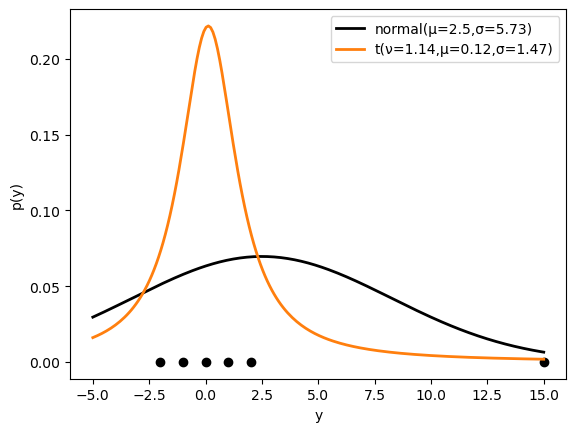

In [26]:
points=[-2,-1,0,1,2,15]
x=np.linspace(-5,15,20*10)
plt.plot(x,stats.norm.pdf(x,loc=2.5,scale=5.73), 'k', label='normal(μ=2.5,σ=5.73)',lw=2)
plt.plot(x,stats.t.pdf(x,df=1.14,loc=0.12,scale=1.47), 'C1', label='t(ν=1.14,μ=0.12,σ=1.47)',lw=2)
plt.scatter(points, np.zeros(len(points)), color='black')
plt.xlabel('y')
plt.ylabel('p(y)')
plt.legend(loc='best')
plt.show()

* The scale parameter of Student-T distribution is not its standard deviation


* The standard deviation of a distribution is the square root of its
  variance, which is the expected value of the squared deviation from
  the mean, formally, $\text{var}_x = \int \, dx \, p(x) \,
  (x-E[x])^2$.
  
* The standard deviation of the $t$ distribution is larger than the
  scale $\sigma$ due to the heavy tails.
  * In fact, it goes to infinity for values of the normality parameter
    $1 \leq \nu < 2$.

* Nevertheless, the scale does have an intuitive relation to the
  spread of the data. Concretely, the range $\pm\sigma$ covers $58\%$
  of the density of the distribution for $\nu=2$ and $50\%$ for
  $\nu=1$.

<br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Example of with a Student-T likelihood

* When we use Student-T instead of Normal for likelihood, we tell the model that there will be some outliers, and it should not stress too much about it (depending on the shape parameter).


In [27]:
d = pd.read_csv("WaffleDivorce.csv", delimiter=";")

d["A"] = stats.zscore(d["MedianAgeMarriage"])
d["D"] = stats.zscore(d["Divorce"])
d["M"] = stats.zscore(d["Marriage"])

with pm.Model() as m_5_3t:
    a = pm.Normal("a", 0, 0.2)
    bA = pm.Normal("bA", 0, 0.5)
    bM = pm.Normal("bM", 0, 0.5)

    mu = a + bA * d["A"] + bM * d["M"]
    sigma = pm.Exponential("sigma", 1)

    D = pm.StudentT("D", 2, mu=mu, sigma=sigma, observed=d["D"])

    m_5_3t_trace = pm.sample(random_seed = rng, idata_kwargs = { 'log_likelihood': True })


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, bA, bM, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


* The model above just says: we have almost normal data, but there are some outliers ($\nu$ = 2)
* Let's also refit the old one (with a Gaussian likelihood)

In [28]:
with pm.Model() as m_5_3:
    a = pm.Normal("a", 0, 0.2)
    bA = pm.Normal("bA", 0, 0.5)
    bM = pm.Normal("bM", 0, 0.5)

    mu = a + bA * d["A"] + bM * d["M"]
    sigma = pm.Exponential("sigma", 1)

    D = pm.Normal("D", mu, sigma, observed=d["D"])

    # log_likelihood is needed for arviz.loo
    m_5_3_trace = pm.sample(random_seed = rng, idata_kwargs = { 'log_likelihood': True })

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, bA, bM, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


In [29]:
az.loo(m_5_3t_trace, pointwise=True, scale="deviance")

Computed from 4000 posterior samples and 50 observations log-likelihood matrix.

             Estimate       SE
deviance_loo   133.78    11.48
p_loo            6.15        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       50  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

In [30]:
az.loo(m_5_3_trace, pointwise=True, scale="deviance")

Computed from 4000 posterior samples and 50 observations log-likelihood matrix.

             Estimate       SE
deviance_loo   128.39    12.71
p_loo            4.64        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       50  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

* so the fit to Data has decreased a bit, but as we see below, the correlation (bA) became stronger (it does not have to respect outliers)

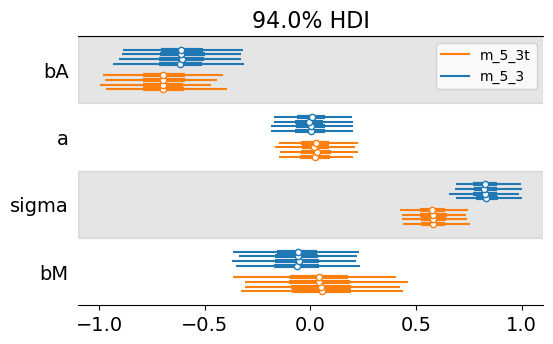

In [31]:
az.plot_forest([m_5_3_trace, m_5_3t_trace], model_names=["m_5_3", "m_5_3t"], figsize=[6, 3.5]);